# BFSI Fraud Pattern Analysis

This notebook applies three ML techniques on transaction behavior attributes:

1. **Hierarchical Clustering** – uncover hidden fraud-like groups using `amount`, `time_gap`, and `device_risk`.
2. **Decision Tree** – explain fraud-related patterns using interpretable rules.
3. **Naive Bayes** – predict fraud likelihood based on transaction characteristics.

Dataset columns detected:
- `amount`
- `time_gap`
- `device_risk`
- `is_fraud`

In [4]:
# Install only if needed:
# !pip install pandas numpy matplotlib scikit-learn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [5]:
# Load dataset
df = pd.read_csv("BFSI.csv")

print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe())

Shape: (5000, 4)


,amount,time_gap,device_risk,is_fraud
0,93.853618,5.002740,0,0
1,602.024286,6.413818,0,0
2,263.349139,19.279050,0,0
3,182.588511,4.155221,0,0
4,33.924974,20.375297,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   amount       5000 non-null   float64
 1   time_gap     5000 non-null   float64
 2   device_risk  5000 non-null   int64  
 3   is_fraud     5000 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 156.4 KB


None

,amount,time_gap,device_risk,is_fraud
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,197.951627,9.652398,0.206200,0.018800
std,197.410226,9.615344,0.404616,0.135832
min,0.002327,0.000528,0.000000,0.000000
25%,55.906498,2.838838,0.000000,0.000000
50%,138.632887,6.654767,0.000000,0.000000
75%,275.745308,13.218993,0.000000,0.000000
max,1634.489120,76.113361,1.000000,1.000000


## 1. Basic Fraud Distribution

Fraud datasets are usually imbalanced. Here we check how many records are fraud and non-fraud.

is_fraud
0    4906
1      94
Name: count, dtype: int64

Fraud percentage:
is_fraud
0    98.12
1     1.88
Name: proportion, dtype: float64


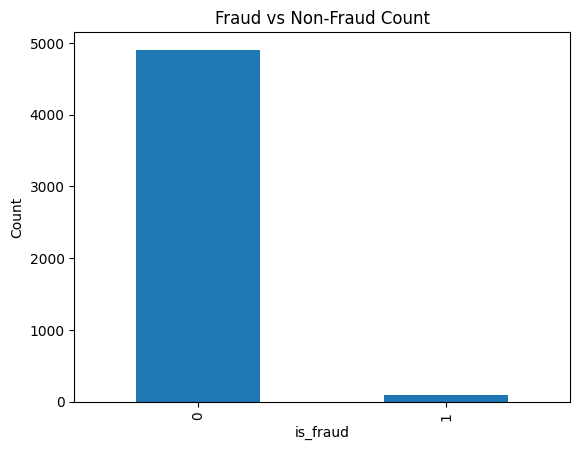

In [6]:
print(df['is_fraud'].value_counts())
print("\nFraud percentage:")
print(df['is_fraud'].value_counts(normalize=True) * 100)

df['is_fraud'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud Count")
plt.xlabel("is_fraud")
plt.ylabel("Count")
plt.show()

## 2. Feature Selection and Scaling

For clustering and classification, we use behavioral attributes:

- `amount`
- `time_gap`
- `device_risk`

Scaling is important because `amount` and `time_gap` are on different numerical ranges.

In [7]:
features = ['amount', 'time_gap', 'device_risk']
target = 'is_fraud'

X = df[features]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
display(X_scaled_df.head())

,amount,time_gap,device_risk
0,-0.527371,-0.483615,-0.50967
1,2.047073,-0.336847,-0.50967
2,0.331310,1.001276,-0.50967
3,-0.077831,-0.571766,-0.50967
4,-0.830975,1.115298,-0.50967


# Part A: Hierarchical Clustering

## Objective
Cluster transactions based on behavioral attributes to uncover hidden fraud patterns.

Hierarchical clustering creates nested clusters. We use:
- **Ward linkage** to minimize within-cluster variance
- **Euclidean distance** on scaled features

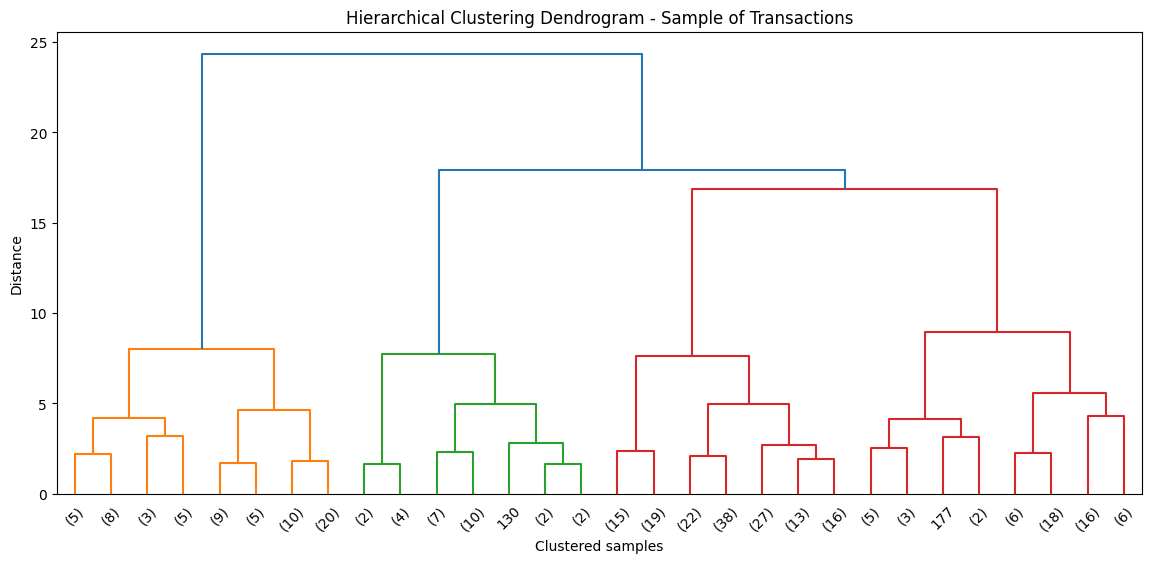

In [8]:
# Dendrogram using sample records for readability
sample_size = 300
sample_X = X_scaled_df.sample(sample_size, random_state=42)

linked = linkage(sample_X, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("Hierarchical Clustering Dendrogram - Sample of Transactions")
plt.xlabel("Clustered samples")
plt.ylabel("Distance")
plt.show()

## Apply Agglomerative Clustering

We choose 3 clusters as a starting point:
- Cluster may represent normal behavior
- Cluster may represent medium-risk behavior
- Cluster may represent suspicious/high-risk behavior

In [9]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['hc_cluster'] = hc.fit_predict(X_scaled)

display(df.groupby('hc_cluster')[features + ['is_fraud']].mean())
display(df.groupby('hc_cluster')['is_fraud'].agg(['count', 'sum', 'mean']).rename(columns={'sum':'fraud_count', 'mean':'fraud_rate'}))

,amount,time_gap,device_risk,is_fraud
hc_cluster,,,,
0,215.995791,6.378445,0.000000,0.000000
1,191.524263,6.969067,1.000000,0.101512
2,131.227681,26.231455,0.131744,0.000000


,count,fraud_count,fraud_rate
hc_cluster,,,
0,3277,0,0.000000
1,926,94,0.101512
2,797,0,0.000000


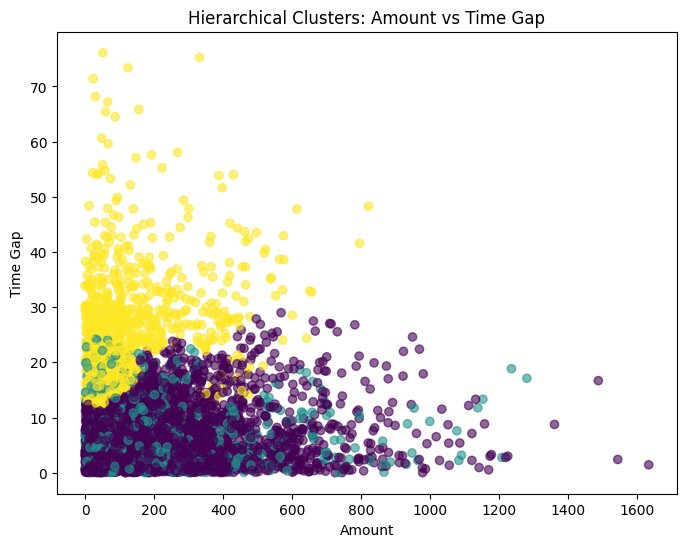

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(df['amount'], df['time_gap'], c=df['hc_cluster'], alpha=0.6)
plt.title("Hierarchical Clusters: Amount vs Time Gap")
plt.xlabel("Amount")
plt.ylabel("Time Gap")
plt.show()

## Hierarchical Clustering Interpretation

Look for clusters with:
- Higher average `amount`
- Higher `device_risk`
- Higher fraud rate
- Unusual `time_gap`

The cluster with the highest fraud rate can be treated as a **fraud-pattern cluster**.

In [10]:
cluster_summary = df.groupby('hc_cluster').agg(
    transaction_count=('is_fraud', 'count'),
    fraud_count=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean'),
    avg_amount=('amount', 'mean'),
    avg_time_gap=('time_gap', 'mean'),
    avg_device_risk=('device_risk', 'mean')
).sort_values('fraud_rate', ascending=False)

display(cluster_summary)

,transaction_count,fraud_count,fraud_rate,avg_amount,avg_time_gap,avg_device_risk
hc_cluster,,,,,,
1,926,94,0.101512,191.524263,6.969067,1.000000
0,3277,0,0.000000,215.995791,6.378445,0.000000
2,797,0,0.000000,131.227681,26.231455,0.131744


# Part B: Decision Tree

## Objective
Build an interpretable model to explain fraud-related clusters and identify key drivers of suspicious activity.

Here the target is `is_fraud`.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9984
Decision Tree ROC-AUC: 0.9565217391304348

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      0.91      0.95        23

    accuracy                           1.00      1250
   macro avg       1.00      0.96      0.98      1250
weighted avg       1.00      1.00      1.00      1250


Confusion Matrix:
[[1227    0]
 [   2   21]]


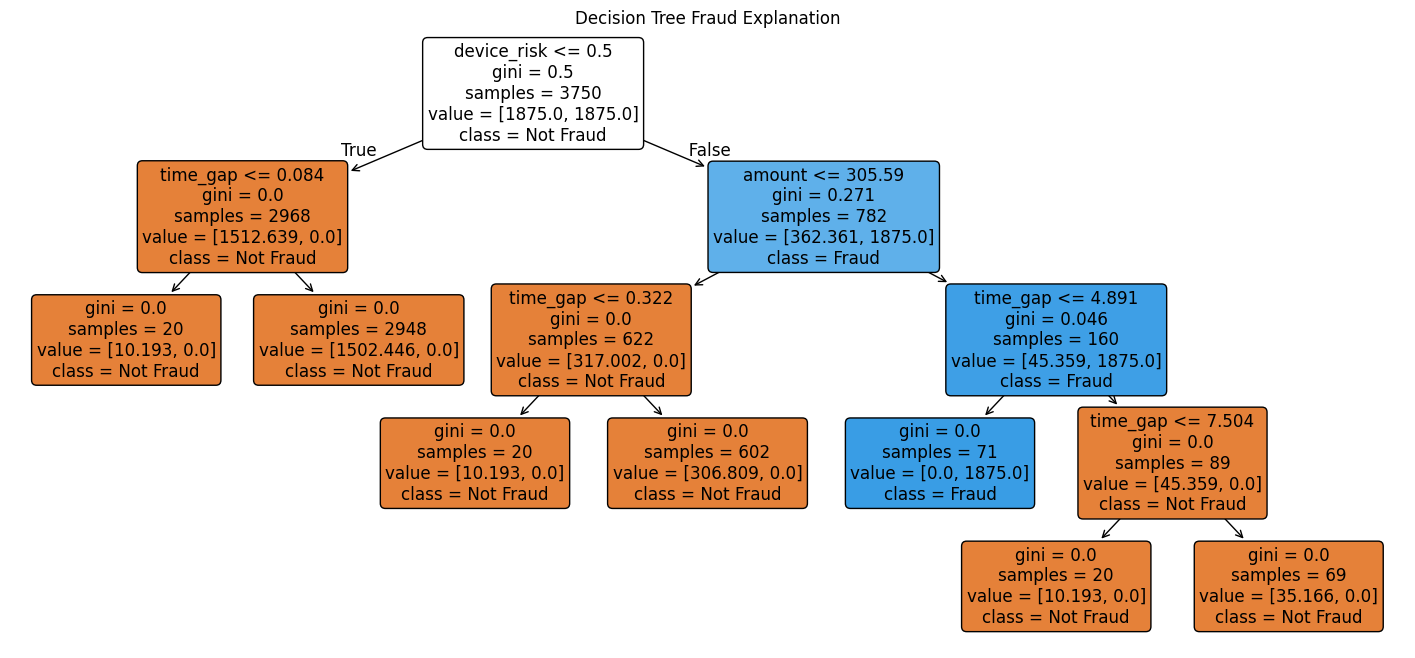

In [11]:
plt.figure(figsize=(18, 8))
plot_tree(
    dt,
    feature_names=features,
    class_names=['Not Fraud', 'Fraud'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Fraud Explanation")
plt.show()

In [12]:
rules = export_text(dt, feature_names=features)
print(rules)

|--- device_risk <= 0.50
|   |--- time_gap <= 0.08
|   |   |--- class: 0
|   |--- time_gap >  0.08
|   |   |--- class: 0
|--- device_risk >  0.50
|   |--- amount <= 305.59
|   |   |--- time_gap <= 0.32
|   |   |   |--- class: 0
|   |   |--- time_gap >  0.32
|   |   |   |--- class: 0
|   |--- amount >  305.59
|   |   |--- time_gap <= 4.89
|   |   |   |--- class: 1
|   |   |--- time_gap >  4.89
|   |   |   |--- time_gap <= 7.50
|   |   |   |   |--- class: 0
|   |   |   |--- time_gap >  7.50
|   |   |   |   |--- class: 0



## Feature Importance

Decision Tree feature importance tells which transaction attributes are most useful for fraud explanation.

,feature,importance
2,device_risk,0.676082
0,amount,0.276678
1,time_gap,0.047240


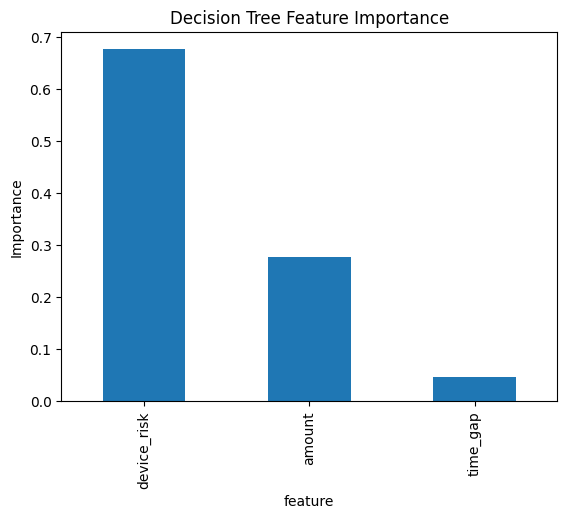

In [13]:
importance_df = pd.DataFrame({
    'feature': features,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df)

importance_df.plot(kind='bar', x='feature', y='importance', legend=False)
plt.title("Decision Tree Feature Importance")
plt.ylabel("Importance")
plt.show()

# Part C: Naive Bayes

## Objective
Develop a classification model to predict fraud likelihood.

Naive Bayes estimates probability of fraud using feature distributions.  
We use **Gaussian Naive Bayes** because `amount` and `time_gap` are continuous numeric features.

In [14]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes ROC-AUC:", roc_auc_score(y_test, y_prob_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9352
Naive Bayes ROC-AUC: 0.9969526239325326

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97      1227
           1       0.22      1.00      0.36        23

    accuracy                           0.94      1250
   macro avg       0.61      0.97      0.66      1250
weighted avg       0.99      0.94      0.95      1250


Confusion Matrix:
[[1146   81]
 [   0   23]]


## Fraud Probability Output

Instead of only predicting 0 or 1, Naive Bayes can produce fraud probability.
This is useful for risk scoring.

In [15]:
result_df = X_test.copy()
result_df['actual_fraud'] = y_test.values
result_df['predicted_fraud'] = y_pred_nb
result_df['fraud_probability'] = y_prob_nb

display(result_df.sort_values('fraud_probability', ascending=False).head(20))

,amount,time_gap,device_risk,actual_fraud,predicted_fraud,fraud_probability
69,866.829268,0.120756,1,1,1,0.999770
1827,691.482306,2.402102,1,1,1,0.999512
471,700.505385,3.751797,1,1,1,0.999104
3952,735.315851,0.053384,1,1,1,0.998976
4802,480.325353,1.402308,1,1,1,0.995736
4859,436.905202,1.683498,1,1,1,0.994274
2075,408.936036,2.016575,1,1,1,0.993072
2481,419.261525,1.487849,1,1,1,0.992902
4016,434.462491,1.095635,1,1,1,0.992530
1223,575.113687,4.568456,1,1,1,0.992296


# Final Business Interpretation

## Hierarchical Clustering
Helps uncover hidden transaction behavior groups.  
A cluster with high `device_risk`, unusual `amount`, and high fraud rate can represent suspicious transaction behavior.

## Decision Tree
Provides explainable fraud rules.  
It helps answer:
- Which feature drives suspicious activity?
- What threshold values increase fraud risk?
- Which customer/transaction segment needs review?

## Naive Bayes
Provides probability-based fraud prediction.  
It is simple, fast, and useful as a baseline fraud-risk scoring model.

